<a href="https://www.kaggle.com/code/abhiramanil369/bertopic-variant-implementation?scriptVersionId=307147370" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install sentence-transformers scikit-learn pandas matplotlib seaborn -q

In [3]:
import random
import pandas as pd

templates = {
    "Finance": [
        "Your account was debited ₹{} for transaction at {}",
        "UPI payment of ₹{} received from {}",
        "Your credit card bill of ₹{} is due on {}",
    ],
    "Work": [
        "Meeting with {} scheduled at {}",
        "{} commented on your PR: '{}'",
        "Reminder: {} deadline is tomorrow",
    ],
    "Shopping": [
        "Your order #{} has been shipped via {}",
        "Exclusive {} sale — up to {}% off today only",
        "{} delivery arriving between {} and {}",
    ],
    "Family": [
        "{} sent you a voice message",
        "Mom: Don't forget {} tonight",
        "{} added you to group '{}'",
    ],
    "Urgent": [
        "OTP for your {} login is {}",
        "Security alert: New sign-in to your {} account",
        "Low battery: {} is at {}%",
    ],
}

names = ["Rahul", "Priya", "Arjun", "Neha", "Vikram", "Ananya"]
apps  = ["Swiggy", "Zomato", "HDFC", "Paytm", "GitHub", "Amazon"]
items = ["Pizza", "Laptop", "Shirt", "Phone case"]

rows = []
for _ in range(2000):
    cat = random.choice(list(templates.keys()))
    tmpl = random.choice(templates[cat])
    slots = tmpl.count("{}")
    fills = [random.choice(names + apps + items + [str(random.randint(100, 9999))])
             for _ in range(slots)]
    text = tmpl.format(*fills)
    rows.append({"text": text, "true_label": cat})

df = pd.DataFrame(rows).sample(frac=1).reset_index(drop=True)
print(df.head())

                                            text true_label
0  Your order #Shirt has been shipped via Laptop   Shopping
1               OTP for your HDFC login is Rahul     Urgent
2           Reminder: Rahul deadline is tomorrow       Work
3              OTP for your 7501 login is Laptop     Urgent
4                Laptop sent you a voice message     Family


In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")  # 22 MB — same as the paper
embeddings = model.encode(df["text"].tolist(), batch_size=64, show_progress_bar=True)
print("Embedding shape:", embeddings.shape)  # (2000, 384)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (2000, 384)


In [5]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=50, random_state=42)
reduced = pca.fit_transform(embeddings)

explained = np.cumsum(pca.explained_variance_ratio_)[-1]
print(f"Variance retained with 50 components: {explained:.1%}")
# Paper claims ~95% — you should see similar results

Variance retained with 50 components: 95.3%


In [6]:
from sklearn.cluster import KMeans

K = 10  # paper uses 5–15; start with 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init="auto")
df["topic_id"] = kmeans.fit_predict(reduced)
print(df["topic_id"].value_counts())

topic_id
7    381
3    276
1    275
2    252
4    147
0    144
6    139
5    136
8    133
9    117
Name: count, dtype: int64


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df["text"])
feature_names = vectorizer.get_feature_names_out()

topic_keywords = {}
for topic_id in range(K):
    mask = df["topic_id"] == topic_id
    cluster_tfidf = tfidf_matrix[mask.values].toarray().mean(axis=0)
    top_indices = cluster_tfidf.argsort()[-5:][::-1]
    topic_keywords[topic_id] = [feature_names[i] for i in top_indices]
    print(f"Topic {topic_id}: {topic_keywords[topic_id]}")

Topic 0: ['sale', 'today', 'exclusive', 'pizza', 'amazon']
Topic 1: ['shipped', 'order', 'arriving', 'delivery', 'zomato']
Topic 2: ['payment', 'received', 'upi', 'card', 'credit']
Topic 3: ['voice', 'sent', 'message', 'added', 'group']
Topic 4: ['login', 'otp', 'pizza', 'laptop', 'shirt']
Topic 5: ['alert', 'new', 'security', 'sign', 'account']
Topic 6: ['mom', 'don', 'tonight', 'forget', 'amazon']
Topic 7: ['commented', 'pr', 'scheduled', 'meeting', 'deadline']
Topic 8: ['debited', 'transaction', 'account', 'neha', 'amazon']
Topic 9: ['battery', 'low', 'paytm', 'github', 'laptop']


In [8]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

sil = silhouette_score(reduced, df["topic_id"], sample_size=500)
print(f"Silhouette score: {sil:.3f}")  # Higher = better separation

# If you have true labels, compute ARI
ari = adjusted_rand_score(df["true_label"], df["topic_id"])
print(f"Adjusted Rand Index: {ari:.3f}")

Silhouette score: 0.171
Adjusted Rand Index: 0.696


2026-03-28 07:12:49.440236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774681969.811117      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774681969.910653      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774681970.780135      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774681970.780194      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774681970.780196      17 computation_placer.cc:177] computation placer alr

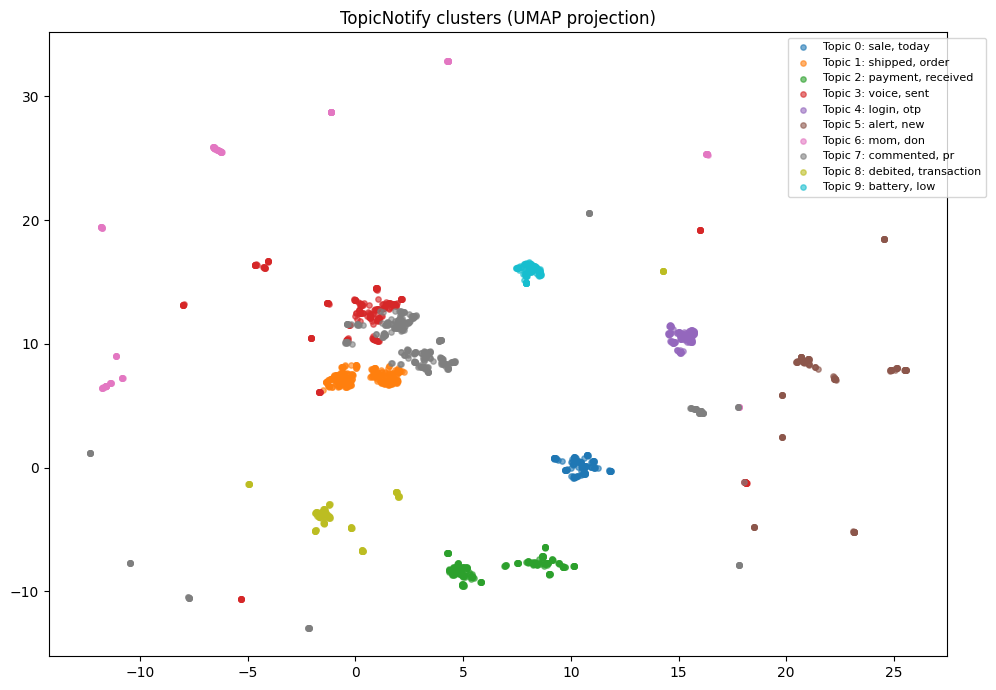

In [9]:
!pip install umap-learn -q
import umap
import matplotlib.pyplot as plt
import seaborn as sns

reducer = umap.UMAP(random_state=42)
coords = reducer.fit_transform(reduced)

plt.figure(figsize=(10, 7))
palette = sns.color_palette("tab10", K)
for i in range(K):
    mask = df["topic_id"] == i
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=f"Topic {i}: {', '.join(topic_keywords[i][:2])}",
                alpha=0.6, s=15, color=palette[i])
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.title("TopicNotify clusters (UMAP projection)")
plt.tight_layout()
plt.savefig("topic_clusters.png", dpi=150)
plt.show()

In [10]:
df["keywords"] = df["topic_id"].map(
    lambda i: ", ".join(topic_keywords[i])
)

topic_table = (
    df.groupby(["topic_id", "keywords"])
    .agg(count=("text", "count"),
         sample=("text", lambda x: x.iloc[0]))
    .reset_index()
    .sort_values("count", ascending=False)
)
print(topic_table.to_string(index=False))

 topic_id                                    keywords  count                                                         sample
        7 commented, pr, scheduled, meeting, deadline    381                           Reminder: Rahul deadline is tomorrow
        3          voice, sent, message, added, group    276                                Laptop sent you a voice message
        1  shipped, order, arriving, delivery, zomato    275                  Your order #Shirt has been shipped via Laptop
        2        payment, received, upi, card, credit    252                Your credit card bill of ₹Paytm is due on Shirt
        4            login, otp, pizza, laptop, shirt    147                               OTP for your HDFC login is Rahul
        0       sale, today, exclusive, pizza, amazon    144              Exclusive Paytm sale — up to 1638% off today only
        6           mom, don, tonight, forget, amazon    139                                Mom: Don't forget Shirt tonight
        